# Point Group Symmetry and Monte Carlo noise in DCA++

#### Key question
How much sampling variance does point-group symmetrization remove from a QMC Green's function, and how does it differ across models and physical parameters?

#### Summary of findings
- We introduce $R \;=\; \frac{\sum_x \operatorname{Var}\big(G[x]\big)}{\sum_x \operatorname{Var}\big(\mathrm{S}\,G[x]\big)}$, the ratio of variance in the SP Green's function with symmetry off/on. $R$ maps directly to a "compute savings factor," and $\sqrt{R}$ maps to an "error reduction factor."
- $R$ is computed by dumping `G_raw` on every rank. The stack is collected, and a .py helper re-implements symmetry imposition using the point group already derived. The variance on $R$ itself is taken from an ensemble of independently-seeded runs.
- Before measuring $R$, we reason that it must be limited by $\rho$, correlation between orbit mates in the underlying noise, and $m_{\text{ceil}}$, the weighted average orbit size of the given the point group and cluster.
- We find that $R$ varies considerably across models, ranging **1.26 to 3.24** in the models measured. Larger clusters and multi-band models benefit the most.
- We also find that $R$ increases with $\beta$, and suggest that the correlation in Monte Carlo noise at symmetry-related points (noise symmetry?) is worth further study.

#### Contents
1. What $R$ is, and why it's the number we care about
2. How $R$ is computed
3. What we should *expect* $R$ to be
4. The headline values of $R$
5. Unpacking the multi-orbital case
6. Digging deeper: how $R$ changes with $\rho$
7. Appendix

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

sys.path.insert(0, '.')
import hero_lib as HL
import reduction as RED
import mechanism as MECH
import summaries as S

# Chart palette 
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, MUTED, GRID = '#1a1a19', '#6b6a63', '#e5e4df'

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'font.size': 9, 'legend.frameon': False,
})

sq = HL.Run('square_b5_c4')            # single-band square, D4, 4x4
fe = HL.Run('fe_as_b5_c4')             # two-band FeAs, 4x4
tb = HL.OpsView('threeband_b5_c4')     # operator only — raw run too large to ship
c8 = HL.OpsView('square_b5_c8')

# Load output files from DCA++ runs (post-processed with 
# standalone .py helpers to keep the notebook lite)   
MANIFEST = json.loads(Path('data/MANIFEST.json').read_text())
print('data bundle:')
for kind in ('runs', 'ops', 'summaries'):
    for name, rec in MANIFEST[kind].items():
        size = rec.get('size_mb') and f"{rec['size_mb']:.1f} MB" or f"{rec.get('size_kb', 0):.0f} KB"
        print(f'  {kind:10s} {name:28s} {size}')

data bundle:
  runs       square_b5_c4                 8.6 MB
  runs       fe_as_b5_c4                  34.2 MB
  ops        threeband_b5_c4              3 KB
  ops        square_b5_c8                 2 KB
  summaries  seed_ensemble_square.json    116 KB
  summaries  seed_ensemble_fe_as.json     176 KB
  summaries  model_sweep.json             393 KB
  summaries  beta_ladder_square.json      374 KB
  summaries  beta_ladder_fe_as.json       741 KB
  summaries  m_scaling_summary.json       110 KB
  summaries  bath_drift_square.json       293 KB


---
## 1. What $R$ is, and why it's the number we care about

### 1.1 Definition

Let `G[x]` be the raw QMC estimate of the single particle Green's function at entry `x`, and let `S` be the point-group symmetrization operator. Then

$$R \;=\; \frac{\sum_x \operatorname{Var}\big(G[x]\big)}{\sum_x \operatorname{Var}\big(\mathrm{S}\,G[x]\big)}$$

where the numerator and denominator are calculated *on the same entries* (i.e. the same set of QMC samples). Put simply, $R$ is the reduction in variance produced by DCA++ when symmetrization is on.

### 1.2 The variance ratio maps directly to saved compute

Monte Carlo variance falls as `1/n` in the number of samples `n`, so cutting variance by a factor $R$ is worth $R$ times more samples. If we assume warm-up cost is negligible for a large run, then total DCA++ compute cost is linear in `n`. So:

> $R$ is the factor by which you would have to lengthen an unsymmetrized run to match the error bars of a symmetrized one of the same length.

This makes $R$ a useful way to characterize the performance of our symmetrization effort. Of course, we may also care about *increased precision*, in which case we would say:

> $\frac{1}{\sqrt{R}}$ is the factor by which error decreases for a symmetrized run compared to an unsymmetrized one that takes the same number of measurements.


### 1.3 Why the ratio has better properties than either variance alone

- **Scale-free.** Since both variances are estimated from the same samples (more on the design below), run twice as long and both halve. $R$ is a property of the noise structure, not of how long you ran.
- **Paired.** The numerator and denominator have identical noise structure. Common fluctuations cancel, leaving a tighter comparison than two independent symmetrization-on/off experiments would yield.


### 1.4 Why we measure it on $G$

There are many observables that a user of DCA++ may care about, but variance will flow in different ways to each. We choose to measure the variance on $G$ since it in some sense a universal representative of the output of DCA++.

---
## 2. How $R$ is computed

### 2.1 Mechanics

A driver calls `local_G_k_w(symmetrize=false)` on every MPI rank before `finalize()`, yielding a `G_raw`. The per-rank stack is gathered to rank 0 and written out alongside the run. A .py helper outside this notebook reproduces the same `symmetrize()` path that's taken in production, then this notebook processes the results.

Note that:

- **One run gives you the variance of $G$.** DCA seeds per-rank RNG streams by `hash(global_id + seed)`, so given 64 ranks of a run you have 64 independent draws of the same measurement. Variance across the rank axis is therefore the sampling variance of $G$.

- **Multiple runs give you the variance of $R$** A single run gives a single $R$. The spread of $R$ across independent runs is not small, so every headline number below is taken from an *ensemble over independent base seeds*, not a single run. This is what gives us the variance on $R$ itself, which you will see in the results below.

### 2.2 A handful of configuration choices made when setting up the runs to measure $R$

| choice | value | notes |
|---|---|---|
| inverse temperature | **β = 5** | It turns out $R$ depends strongly on β (more on that below). 5 was about as far as we could probe in this analysis on a workstation compute budget. |
| bath | **bare** (`Σ = 0`), one solver call | After finding that a converged DCA++ run did not change the value of $R$, we limited to bare bath / first-iteration runs in order to maximize model coverage. |
| ranks per run | 64 | This needs to be large enough to get a reasonably narrow $\operatorname{Var}(G)$ |
| measurements per rank | 2048 | This turned out to be important for mitigating sign problem in FeAs |
| seeds per ensemble | 32 *(Except for square 8×8, which got 16 due to compute bandwidth)* | Controls precision on $\operatorname{Var}(R)$ |
| sweeps per measurement | 2 | held fixed, not swept |
| warm-up sweeps | 200 square, 80 FeAs, 8000 threeband |  |

### 2.3 Sanity check

Symmetrization must **not move the mean**, and entries that have no orbit mates must show no reduction at all.




In [5]:
# Mean preservation: our numpy symmetrization of the raw ensemble mean must reproduce the finalized
# G_k_w that production wrote. On a model with a sign problem the invariant mean is the PHASE-WEIGHTED
# one -- production forms sum(sign_i G_i)/sum(sign_i), not the plain average of the per-rank points.
for r in (sq, fe):
    ours = HL.full_symmetrize(r, r.phase_weighted_mean())
    gap = np.abs(ours - r.G_final).max() / np.abs(r.G_final).max()
    print(f'{r.model:10s}  max relative gap vs production G_k_w = {gap:.2e}')

print()
# Singleton null control: an orbit of size 1 has nothing to average, so r must be exactly 1.
for r in (sq, fe):
    singles = [o for o in r.orbits() if not o['forced_null'] and len(o['members']) == 1]
    vr = r.variance_ratios()
    A = (vr['var_raw'].real + vr['var_raw'].imag).sum((0, 1))
    B = (vr['var_sym'].real + vr['var_sym'].imag).sum((0, 1))
    if not singles:
        print(f'{r.model:10s}  no singleton orbits — every entry has at least one mate '
              f'(or is a forced null)')
        continue
    ratios = [A[o['members'][0]] / B[o['members'][0]] for o in singles]
    print(f'{r.model:10s}  {len(singles)} singleton orbits, r = '
          f'{min(ratios):.12f} .. {max(ratios):.12f}')

square_D4   max relative gap vs production G_k_w = 4.66e-16
fe_as       max relative gap vs production G_k_w = 4.22e-16

square_D4   2 singleton orbits, r = 1.000000000000 .. 1.000000000000


fe_as       no singleton orbits — every entry has at least one mate (or is a forced null)


---
## 3. What to expect from $R$

### 3.1 $R$ is limited by the correlation of the underlying noise
In principle, we might expect that averaging an orbit of $m = |\text{orbit}|$ symmetry-related entries cuts variance by $m$, but that is true only if the orbit mates fluctuate independently. It turns out they do not. We introduce $\rho$, the pairwise noise correlation between mates, and $r$, the variance reduction for a particular orbit average:

$$r \;=\; \frac{m}{1 + (m-1)\,\rho}$$

When the noise between orbit mates is perfectly independent ($\rho=0$), we recover $r=|\text{orbit}|$. Similarly, $r$ is limited by $\frac{1}{\rho}$

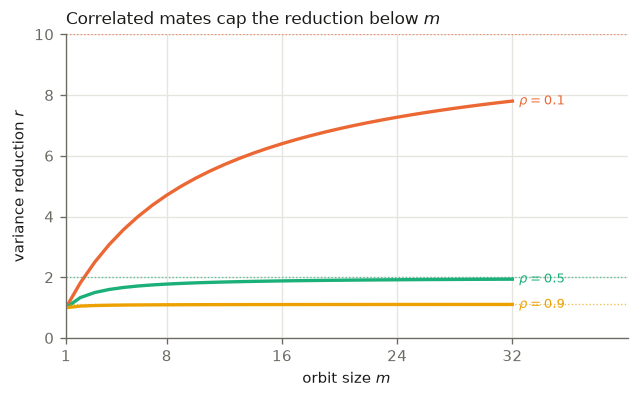

In [17]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
m = np.arange(1, 33)
for rho, color, lab in (
                        (0.1, ORANGE, r'$\rho=0.1$'),
                        (0.5, AQUA, r'$\rho=0.5$'),
                        (0.9, YELLOW, r'$\rho=0.9$')):
    r_vals = HL.predicted_r(m, rho)
    ax.plot(m, r_vals, lw=2, color=color)
    ax.annotate(lab, (m[-1], r_vals[-1]), xytext=(4, 0), textcoords='offset points',
                va='center', fontsize=8, color=color)
    if rho > 0:
        ax.axhline(1 / rho, color=color, lw=0.8, ls=':', alpha=0.7)

ax.set_xlabel('orbit size $m$')
ax.set_ylabel(r'variance reduction $r$')
ax.set_title('Correlated mates cap the reduction below $m$', loc='left', fontsize=10)
ax.set_xlim(1, 40); ax.set_ylim(0, 10)
ax.set_xticks([1, 8, 16, 24, 32])
plt.tight_layout(); plt.show()

### 3.2 $R$ is limited by the geometry and size of its cluster

Section 3.1 treated one orbit at a time. But a cluster does not have an orbit size — it has a
distribution of them, fixed by the cluster definition and point group.

Each momentum is left fixed by some subgroup of the point group — its stabilizer — and its orbit size is `m = |group| / |stabilizer|`. High-symmetry points have large stabilizers and therefore small orbits. On the 4×4 square cluster under D4 (`|group| = 8`), the 16 momenta fall into six orbits in three classes:

| class | momenta | stabilizer | orbit size $m$ |
|---|---|---|---|
| fixed points | $(0,0)$, $(\pi,\pi)$ | all 8 ops | **1** |
| axis pair | $(\pi,0)$, $(0,\pi)$ | 4 ops | 2 |
| generic (3 orbits) | $(\pi/2,0)$, $(\pi/2,\pi/2)$, $(\pi/2,\pi)$ and their images | 2 ops | 4 |

Two immediate consequences:

- **Some entries are never symmetrized at all.** $\Gamma$ and $(\pi,\pi)$ are fixed by every operation in the group, so their orbit is themselves. They contribute `r = 1` regardless of the noise structure. 
- **Not even the best orbit reaches $r = |\text{group}| = 8$.** On this cluster every momentum lies on a mirror line, so the largest orbit here is 4 — half the group order.
- **Larger clusters benefit more from symmetrization.** Sticking with the square example, if we scale up to 8x8, we get proportionally fewer high-symmetry points.  

$R$ is a single ratio over the whole space, so it is a *sum over these classes*, weighted by how much raw variance each one carries. For square 4×4 those orbit sizes combine to at most **$m_{\text{ceil}}$ = 2.97** and for square 8x8 the ceiling reaches **$m_{\text{ceil}}$ = 4.62** 

---
## 4. The headline numbers

We evaluate four models: square 4x4, FeAs 2-band 4x4, threeband Emery 4x4, and square 8x8.

- $R$ is the headline (read as "compute savings factor")
- $\sqrt{R}$ is the companion "precision factor" *(By how much do error bars shrink if we symmetrize at constant number of measurements?)*
- `±` is the standard error of $R$
- $1/\rho$ is the measured noise ceiling and `m-ceiling` the geometric one; **`binds`** names whichever is smaller, and therefore what limits that model.

In [16]:
sweep = {r['label']: r for r in S.design_points()}
fe_head = S.headline('fe_as_b5')
fe_ceilings = S.feas_ceilings()   # same definitions as the sweep, from FeAs's own ensembles

table = [
    ('square, 4x4', sweep['square_b5_c4'], 1),
    ('FeAs 2-band, 4x4', None, 2),
    ('threeband, 4x4', sweep['threeband_b5_c4'], 3),
    ('square, 8x8', sweep['square_b5_c8'], 1),
]

print(f"{'design point':<18} {'nb':>3} {'Nc':>4} {'seeds':>6} {'R':>9} "
      f"{'√R':>18} {'1/rho':>7} {'m-ceil':>7} {'binds':>6}")
print('-' * 102)
for label, rec, nb in table:
    if rec is None:   # FeAs headline comes from its own 32-seed ensemble
        R, sem, n, nk = fe_head['R_full']['mean'], fe_head['R_full']['sem'], fe_head['n_seeds'], 16
        inv_rho, m_ceil, binds = (fe_ceilings['inv_rho'], fe_ceilings['m_ceiling'],
                                  fe_ceilings['binding'])
    else:
        R, sem, n, nk = rec['R_full']['mean'], rec['R_full']['sem'], rec['n_seeds'], rec['nk']
        inv_rho, m_ceil, binds = rec['inv_rho'], rec['m_ceiling'], rec['binding']
    # sqrt(R) is the error-bar factor; R is the measurement-count factor. See section 1.2.
    print(f'{label:<18} {nb:>3} {nk:>4} {n:>6} {R:>10.4f} +/- {sem:<5.4f} '
          f'{np.sqrt(R):>5.2f}x {inv_rho:>7.2f} {m_ceil:>7.2f} {binds:>6}')

design point        nb   Nc  seeds         R                 √R   1/rho  m-ceil  binds
------------------------------------------------------------------------------------------------------
square, 4x4          1   16     32     1.2619 +/- 0.0072  1.12x    1.51    2.97    rho
FeAs 2-band, 4x4     2   16     32     3.0417 +/- 0.0486  1.74x   13.18    3.06      m
threeband, 4x4       3   16     32     3.2380 +/- 0.0359  1.80x    6.21    3.61      m
square, 8x8          1   64     16     1.5006 +/- 0.0130  1.23x    1.88    4.62    rho


**Read the spread first.** At one temperature, on one cluster, with the same point group, $R$ runs from **1.26 to 3.24**. The single-band square-lattice produces the same variance with 26% fewer measurements when symmetrized, while three-band model gets a 3.2× improvement. Variance improvement is highly model-dependent.

**And the reason splits cleanly along band count.** Both single-band points are $\rho$-limited: square 4×4's geometry could support 2.97× but its noise correlation caps it at 1.51×. Both multi-orbital points are `m`-limited, FeAs dramatically so — its noise structure would support **13.2×** and its 4×4 geometry registers "only" 3.06×.

### 4.1 Visualizing the variance reduction

Take one orbit at one frequency and plot every rank's estimate of every mate in the complex plane (with the orbit's signs applied so that odd mates are aligned rather than pointing opposite ways). Symmetrization replaces each of those points with the orbit average. So:

- the cloud **contracts** toward its own center by $1/\sqrt{r}$ *(note: it's $r$ not $R$ here since we're talking about an individual orbit)*
- the center **does not move** — mean is preserved
- a **singleton** orbit shows no contraction at all, the null control

Contrast a $\rho$-limited model with an `m`-limited one and the two ceilings become something you can see: square's mates are so strongly correlated that the cloud barely tightens, while FeAs's `m=8` orbit collapses.

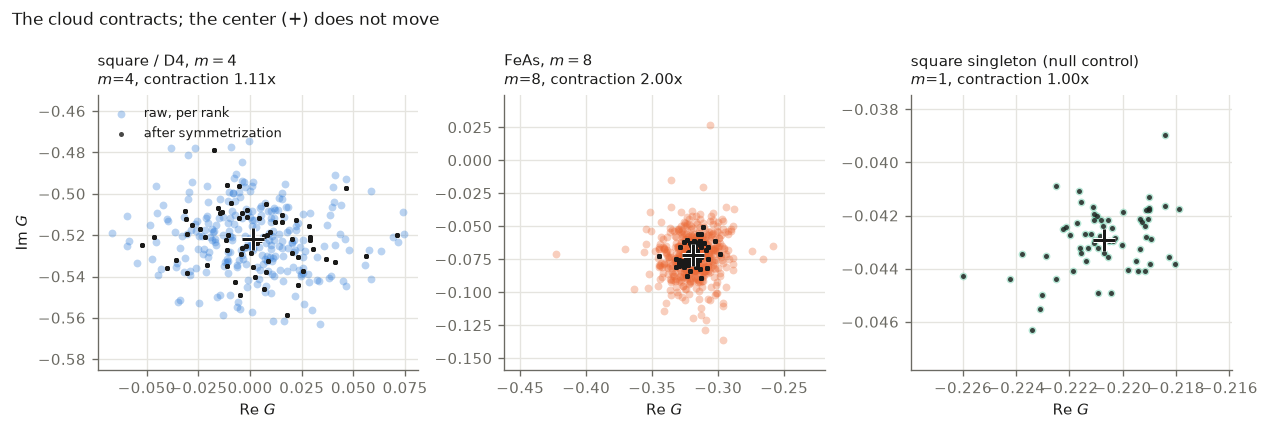

square / D4, $m=4$                m=4  spread 3.085e-02 -> 2.787e-02   center moved by 2.13e-16 (relative)
FeAs, $m=8$                       m=8  spread 2.186e-02 -> 1.091e-02   center moved by 3.42e-16 (relative)
square singleton (null control)   m=1  spread 2.015e-03 -> 2.015e-03   center moved by 0.00e+00 (relative)


In [11]:
def pick_orbit(run, m_want):
    cands = [o for o in run.orbits() if not o['forced_null'] and len(o['members']) == m_want]
    return cands[len(cands) // 2] if cands else None

panels = [
    ('square / D4, $m=4$', sq, pick_orbit(sq, 4), BLUE),
    ('FeAs, $m=8$', fe, pick_orbit(fe, 8), ORANGE),
    ('square singleton (null control)', sq, pick_orbit(sq, 1), AQUA),
]

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
for ax, (title, run, orb, color) in zip(axes, panels):
    mc = MECH.migration_cloud(run, orb)
    pts, sym = mc['points'].ravel(), mc['sym'].ravel()
    ax.scatter(pts.real, pts.imag, s=22, color=color, alpha=0.32, lw=0, label='raw, per rank')
    ax.scatter(sym.real, sym.imag, s=9, color=INK, alpha=0.8, lw=0, label='after symmetrization')
    ax.scatter([mc['centroid'].real], [mc['centroid'].imag], s=170, marker='+',
               color='white', lw=3.0, zorder=5)
    ax.scatter([mc['centroid'].real], [mc['centroid'].imag], s=170, marker='+',
               color=INK, lw=1.8, zorder=6)
    ax.set_title(f"{title}\n$m$={mc['m']}, contraction {mc['contraction']:.2f}x",
                 loc='left', fontsize=9)
    ax.set_xlabel(r'Re $G$'); ax.set_aspect('equal', adjustable='datalim')
axes[0].set_ylabel(r'Im $G$')
axes[0].legend(fontsize=7.5, loc='upper left')
fig.suptitle('The cloud contracts; the center (+) does not move', x=0.01, ha='left', fontsize=10)
plt.tight_layout(); plt.show()

for title, run, orb, _ in panels:
    mc = MECH.migration_cloud(run, orb)
    shift = abs(mc['sym_centroid'] - mc['centroid']) / abs(mc['centroid'])
    print(f"{title:32s}  m={mc['m']}  spread {mc['spread_raw']:.3e} -> {mc['spread_sym']:.3e}"
          f"   center moved by {shift:.2e} (relative)")

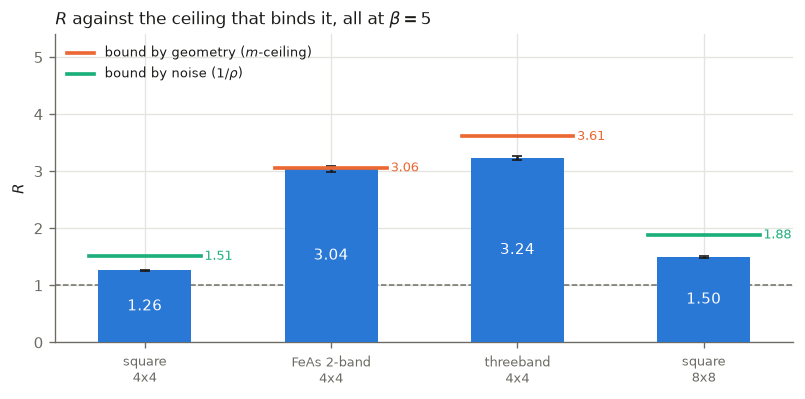

In [10]:
# Only the BINDING ceiling is plotted. Each point has two, and the larger one is not a constraint --
# showing both would also put FeAs's 1/rho = 13.2 off the top of a scale the bars need to share.
rows = []
for label, rec, nb in table:
    if rec is None:
        rows.append(('FeAs 2-band\n4x4', fe_head['R_full']['mean'], fe_head['R_full']['sem'],
                     fe_ceilings['m_ceiling'], fe_ceilings['inv_rho'], fe_ceilings['binding']))
    else:
        short = {'square_b5_c4': 'square\n4x4', 'threeband_b5_c4': 'threeband\n4x4',
                 'square_b5_c8': 'square\n8x8'}[rec['label']]
        rows.append((short, rec['R_full']['mean'], rec['R_full']['sem'],
                     rec['m_ceiling'], rec['inv_rho'], rec['binding']))

fig, ax = plt.subplots(figsize=(6.8, 3.4))
x = np.arange(len(rows))
ax.bar(x, [r[1] for r in rows], width=0.5, color=BLUE, zorder=3,
       yerr=[r[2] for r in rows], ecolor=INK, capsize=3)

for i, (lab, R, sem, mc, irho, binds) in enumerate(rows):
    ceiling = min(mc, irho)
    color = ORANGE if binds == 'm' else AQUA
    ax.plot([i - 0.3, i + 0.3], [ceiling, ceiling], color=color, lw=2.2, zorder=4)
    ax.annotate(f'{ceiling:.2f}', (i + 0.32, ceiling), fontsize=8, color=color, va='center')
    ax.annotate(f'{R:.2f}', (i, R / 2), ha='center', va='center', fontsize=9, color='white')

ax.plot([], [], color=ORANGE, lw=2.2, label='bound by geometry ($m$-ceiling)')
ax.plot([], [], color=AQUA, lw=2.2, label=r'bound by noise ($1/\rho$)')
ax.axhline(1, color=MUTED, lw=0.9, ls='--')
ax.legend(fontsize=8, loc='upper left')
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows], fontsize=8)
ax.set_ylabel('$R$'); ax.set_ylim(0, 5.4)
ax.set_title(r'$R$ against the ceiling that binds it, all at $\beta=5$', loc='left', fontsize=10)
plt.tight_layout(); plt.show()

---
## 5. Unpacking the multi-orbital case

Band count is the single largest lever in the headline table: at fixed β, fixed cluster and the same point group, $R$ goes from **1.26 (nb=1) to 3.04 (nb=2) to 3.24 (nb=3)**.

### 5.1 Multi-orbital enlarges orbits
On a 4×4 cluster every momentum lies on a mirror line, so **single-band square tops out at `m = 4` despite having 8 group operations**. FeAs and threeband reach `m = 8` on the identical cluster, purely because band permutations enlarge the orbits. (Square only reaches `m = 8` by going to an 8×8 cluster, which buys three free orbits — the last row.)

The aggregate consequence is the `m-ceiling` column of section 4, which weights these orbit sizes by how much variance each entry actually carries: 2.97 for square 4×4 against 3.06 for FeAs and 3.61 for threeband, on the identical cluster.

In [13]:
print(f"{'design point':<20} {'orbit sizes (non-null)':<34} {'largest m':>10}")
print('-' * 66)
for label, o in (('square 4x4', sq), ('FeAs 4x4', fe), ('threeband 4x4', tb), ('square 8x8', c8)):
    h = HL.orbit_size_histogram(HL.orbits_from_P(o.P))
    txt = '  '.join(f'm={k}: {v}' for k, v in h.items())
    print(f'{label:<20} {txt:<34} {max(h):>10}')

design point         orbit sizes (non-null)              largest m
------------------------------------------------------------------
square 4x4           m=1: 2  m=2: 1  m=4: 3                      4
FeAs 4x4             m=2: 4  m=4: 4  m=8: 2                      8
threeband 4x4        m=1: 2  m=2: 10  m=4: 15  m=8: 4            8
square 8x8           m=1: 2  m=2: 1  m=4: 9  m=8: 3              8


### 5.2 Symmetry-forbidden entries: noise driven to exactly zero

A multi-orbital model has entries that the group maps onto *minus themselves*. Their expectation is exactly zero, so symmetrization does not just average their noise down — it drives variance for that symmetry orbit to 0.

threeband has 30 "forced-null" entries carrying **20.5%** of the total raw variance; FeAs has 24, carrying 16%.

In [20]:
tb_rows = S.class_table('threeband_b5_c4')
print('\nthreeband, R by entry class (32 seeds):')
print(f"  {'class':<32} {'n':>4} {'var share':>10} {'R_class':>16} {'mean m':>7}")
for r in tb_rows:
    rc = 'inf (exactly 0)' if not np.isfinite(r['R_C']) else f"{r['R_C']:.3f} +/- {r['R_C_sem']:.3f}"
    print(f"  {r['cls']:<32} {r['n']:>4} {r['w']*100.00:>9.2f}% {rc:>16} {r['mean_m']:>7.2f}")


threeband, R by entry class (32 seeds):
  class                               n  var share          R_class  mean m
  diagonal, band-orbit >1            32     48.16%  2.513 +/- 0.030    4.50
  forced null                        30     20.47%  inf (exactly 0)    1.00
  off-diagonal, inequivalent         48     15.09%  3.331 +/- 0.031    5.00
  off-diagonal, equivalent           18     10.63%  3.375 +/- 0.049    5.56
  diagonal, band-orbit 1             16      5.65%  1.408 +/- 0.010    3.38


### 5.3 Multi-band's off-diagonal classes symmetrize best
The class table shows how the headline $R$ understates the model in some sense. Around half the raw variance (48%) sits in the band-diagonal p blocks at $R_\mathrm{class} = 2.51$. The two off-diagonal classes reduce better at ~3.3, but carry only 26% between them.

***Are there cases when we care about the variance in a particular orbit class more so than in aggregate?*** If so, this view becomes instructive.

---
## 6. Digging deeper

### 6.1 $R$ increases as temperature decreases

Though the above results are all shown for β=5, a natural question is whether there is a relationship between $R$ and temperature, especially for models that are $\rho$-limited. We find that (at least in the high temperature range we stepped through) $\rho$ drops with β, meaning $R$ improves as the physics get colder.

This finding deserves more unpacking, but at the surface points to the interesting observation that **Monte Carlo shares some intrinsic symmetry with the point group which degrades as temperature drops**. (Or perhaps that noise has a k-dependence that decreases as temperature decreases, or that its noise shifts from momentum-dependence to real-space dependence? Different ways of saying the same thing.)

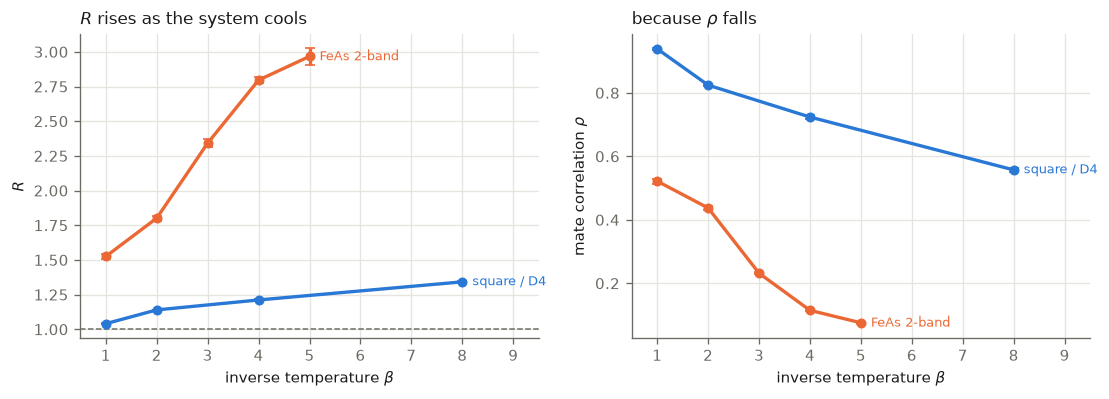

square:
  beta=1  R = 1.0414 +/- 0.0015   rho = 0.939
  beta=2  R = 1.1406 +/- 0.0029   rho = 0.825
  beta=4  R = 1.2122 +/- 0.0065   rho = 0.724
  beta=8  R = 1.3429 +/- 0.0088   rho = 0.557
FeAs:
  beta=1  R = 1.5259 +/- 0.0157   rho = 0.522
  beta=2  R = 1.8021 +/- 0.0186   rho = 0.438
  beta=3  R = 2.3427 +/- 0.0267   rho = 0.232
  beta=4  R = 2.7971 +/- 0.0188   rho = 0.115
  beta=5  R = 2.9679 +/- 0.0592   rho = 0.076


In [6]:
lad_sq, lad_fe = S.beta_ladder('square'), S.beta_ladder('fe_as')

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4))
for ax, key, ylab, title in ((axes[0], 'R_full', '$R$', r'$R$ rises as the system cools'),
                             (axes[1], 'rho', r'mate correlation $\rho$',
                              r'because $\rho$ falls')):
    for lad, color, name in ((lad_sq, BLUE, 'square / D4'), (lad_fe, ORANGE, 'FeAs 2-band')):
        b = [r['beta'] for r in lad]
        v = [r[key] for r in lad]
        e = [r.get(key + '_sem', 0) for r in lad]
        ax.errorbar(b, v, yerr=e, lw=2, color=color, marker='o', ms=5, capsize=3, label=name)
        ax.annotate(name, (b[-1], v[-1]), xytext=(6, 0), textcoords='offset points',
                    fontsize=8, color=color, va='center')
    ax.set_xlabel(r'inverse temperature $\beta$'); ax.set_ylabel(ylab)
    ax.set_title(title, loc='left', fontsize=10); ax.set_xlim(0.5, 9.5)
axes[0].axhline(1, color=MUTED, lw=0.9, ls='--')
plt.tight_layout(); plt.show()

for name, lad in (('square', lad_sq), ('FeAs', lad_fe)):
    print(f'{name}:')
    for r in lad:
        print(f"  beta={r['beta']:.0f}  R = {r['R_full']:.4f} +/- {r['R_full_sem']:.4f}   "
              f"rho = {r['rho']:.3f}")

### 6.2 Where $\rho$ comes from

We can think of $\rho$ as the share of MC noise that already has point group symmetric structure, and therefore cannot be reduced by symmetry averaging. There appears to be a class of (temperature-dependent) physical fluctuation that is structurally invisible to any symmetrization. Where this underlying structure comes from is beyond the scope of this analysis, but we note that it is an interesting finding worth exploring further. (Are there ties to disorder or the sign problem that can be made here?)

By way of providing at least one simple diagnostic, we ask **are symmetry mates more correlated than generic paired points?** If the noise carried no particular alignment with the point group, we would expect random pairs of momenta to correlate just as much as symmetry mates do. As it turns out, the correlation is significantly stronger among symmetry mates:

In [18]:
print(f"{'':10s} {'mate rho':>10} {'generic-pair rho':>18} {'ratio':>7}")
for run, name in ((sq, 'square'), (fe, 'FeAs')):
    mates = [run.orbit_rho(o['members'], o['signs'])
             for o in run.orbits() if not o['forced_null'] and len(o['members']) > 1]
    mate, generic = float(np.mean(mates)), MECH.pairwise_rho_all_k(run)
    print(f'{name:10s} {mate:>10.3f} {generic:>18.3f} {mate/generic:>6.1f}x')

             mate rho   generic-pair rho   ratio


square          0.664              0.107    6.2x
FeAs            0.078              0.032    2.4x


On square, symmetry mates correlate **6.2× more strongly** than generic momentum pairs — the noise is sharply aligned with the point group, and it is exactly the component symmetrization cannot touch. On FeAs the same ratio is 2.4×. The models differ in the *symmetry structure of their noise*, not just in their symmetry structure.

---
## 7. Appendix

### 7.1 Why the bare bath is a fair place to measure

Every number in this notebook comes from one solver call at the bare bath (`Σ = 0`), not from a converged self-consistent loop. That makes the calculations tractable without Frontier, but it's not how DCA++ is actually used so we must verify that the bare-bath calculation of $R$ is an honest representation of the $R$ a user would get on a converged run.

The check is straightforward: run an actual `DcaLoop` and measure $R$ at every iteration. This one is **square at β = 8** — 8 seeds, 10 iterations.

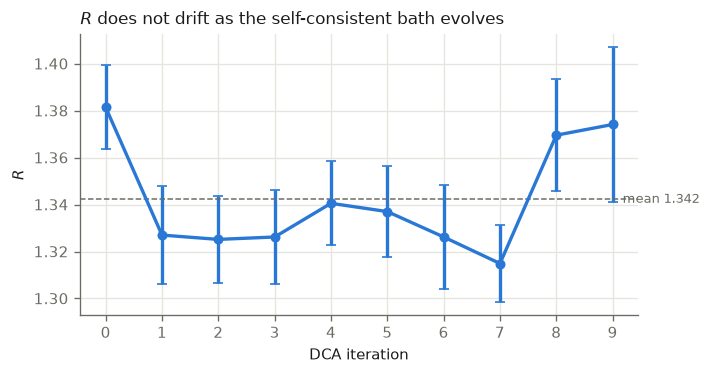

paired within-seed drift across iterations: -0.0073 [-0.1022, +0.0876]  (n=8)
cost-weighted mean R over iterations: 1.3422 +/- 0.0064


In [21]:
bd = S.bath_drift()
it = bd['by_iteration']
fig, ax = plt.subplots(figsize=(6.0, 3.2))
k = [r['iteration'] for r in it]
v = [r['R_full'] for r in it]
e = [r['R_full_sem'] for r in it]
ax.errorbar(k, v, yerr=e, lw=2, marker='o', ms=5, color=BLUE, capsize=3)
ax.axhline(np.mean(v), color=MUTED, lw=0.9, ls='--')
ax.annotate(f'mean {np.mean(v):.3f}', (k[-1], np.mean(v)), xytext=(6, 0),
            textcoords='offset points', fontsize=8, color=MUTED, va='center')
ax.set_xlabel('DCA iteration'); ax.set_ylabel('$R$')
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_title('$R$ does not drift as the self-consistent bath evolves', loc='left', fontsize=10)
plt.tight_layout(); plt.show()

p = bd['paired']
print(f"paired within-seed drift across iterations: {p['mean']:+.4f} "
      f"[{p['lo']:+.4f}, {p['hi']:+.4f}]  (n={p['n']})")
print(f"cost-weighted mean R over iterations: {bd['cost_weighted']['mean']:.4f} "
      f"+/- {bd['cost_weighted']['sem']:.4f}")

The drift is consistent with zero. Iterations are serially dependent, so the interval quoted is the **paired within-seed** one — ranks are matched streams across iterations, and pairing is what makes the comparison legitimate.

So the bare-bath convention costs nothing: a single-iteration measurement transfers to the iterations a production run actually performs.

### 7.2 Summary of how DCA++ was patched

Minimal patch to enable the requisite data dump. Planning to commit these to prod to enable future analysis.

| change | file | what it does |
|---|---|---|
| `local_G_k_w(bool symmetrize = false)` | `ctaux_cluster_solver.hpp` | the method already existed, marked *"For testing purposes"*; we added the flag and threaded it into `compute_G_k_w_new` so it can skip `Symmetrize::execute` |
| `local_accumulated_sign()` | `ctaux_cluster_solver.hpp` | a 3-line accessor exposing the per-rank accumulated phase, so production's *global* sign normalization can be rebuilt from per-rank samples |
| a latent-bug fix | `ctaux_cluster_solver.hpp` | the pre-existing normalization line **never compiled** — the method had never been instantiated, since every real caller goes through `finalize()`. Corrected to the same `get_accumulated_phase()` form the proven `computeErrorBars` path uses |
| two optional loop hooks | `dca_loop.hpp` | let an out-of-tree driver sample each DCA iteration without reimplementing `execute()`. **Used only for the bare bath / iterations measurement**. |